# Inference for proportions on different data: who survived?

*Part 2 · Lesson 14 · another dataset  ·  data: Titanic*

*↩ A companion to [Lesson 14: Inference for proportions (one & two)](14-inference-proportions.ipynb).*

**↩ Back:** [Lesson 14: Inference for proportions (one & two)](14-inference-proportions.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](14-inference-proportions~the-code.ipynb)

In the core lesson we asked whether the low-birth-weight **rate** differed for smokers and nonsmokers —
a real but **subtle** gap that the test had to work to confirm. Here we run the very same machinery on a
question with a famously **blunt** answer: of the people aboard the **Titanic**, what fraction **survived**,
and was a woman's chance of survival different from a man's?

We'll estimate a proportion, wrap it in a **confidence interval**, and run a **z-test** against a
benchmark — first for **one** group (everyone), then for the **difference between two** (women vs. men).
The contrast with the births lesson is the whole point: that gap was borderline; **this one is enormous**.
When an effect is this large, "is it statistically significant?" stops being interesting — the answer is
*obviously yes* — and the useful question becomes **how big** the gap is and **how precisely** we've
pinned it down. Our data: the **887 passengers** on the Titanic with known fate.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
sl.use_course_style()

TITANIC_URL = 'https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv'
tit = sl.load_csv('titanic.csv', url=TITANIC_URL)

print(f'{len(tit):,} passengers, {tit.shape[1]} columns')
# The two columns we'll lean on, and the exact values they take:
print('Survived values:', sorted(tit['Survived'].dropna().unique()), '  (1 = survived, 0 = did not)')
print('Sex values:     ', list(tit['Sex'].dropna().unique()))
tit[['Survived', 'Sex', 'Pclass', 'Age']].head()

887 passengers, 8 columns
Survived values: [np.int64(0), np.int64(1)]   (1 = survived, 0 = did not)
Sex values:      ['male', 'female']


,Survived,Sex,Pclass,Age
0,0,male,3,22.0
1,1,female,1,38.0
2,1,female,3,26.0
3,1,female,1,35.0
4,0,male,3,35.0


## What is a proportion, and what are we inferring?

A **proportion** is just the fraction of items in a category — here, the fraction of passengers who
**survived**. Handily, the `Survived` column is already a **1/0 indicator**: 1 means survived, 0 means
did not. A "success" in statistics just means "the event we're counting" — here, surviving — with no
cheerfulness implied.

Two words we'll use constantly:

- $p$ — the **true** proportion in the whole population. We **don't** know it.
- $\hat{p}$ (read "p-hat") — the **sample** proportion: the fraction who survived in our data. This is
  our **estimate** of $p$.

A subtle point worth naming: these 887 people aren't a random sample of some larger group — they *are*
essentially everyone aboard with a recorded fate. So you can read the inference two ways: either as a
formal estimate of an imagined "population of Titanic-like voyages," or simply as a way to ask *how much
of the pattern we see could be sampling noise.* Either way the arithmetic is identical, so let's count.

In [2]:
surv = tit['Survived'].to_numpy()      # already 1 = survived, 0 = did not

n = len(surv)            # number of passengers
x = int(surv.sum())      # number who survived
phat = x / n             # the sample proportion p-hat
print(f'survivors: x = {x} out of n = {n}')
print(f'sample proportion  p-hat = {phat:.4f}   (about {phat*100:.1f}%)')
print('\nSo only about 2 in 5 aboard survived -- the disaster was, overall, deadly.')

survivors: x = 342 out of n = 887
sample proportion  p-hat = 0.3856   (about 38.6%)

So only about 2 in 5 aboard survived -- the disaster was, overall, deadly.


## 1) How much does $\hat{p}$ wobble? The standard error

If we could re-run "a voyage like this" over and over, each would hand back a slightly different
$\hat{p}$. The typical size of that wobble is the **standard error (SE)** of the proportion:

$$\text{SE}(\hat{p}) = \sqrt{\dfrac{\hat{p}\,(1-\hat{p})}{n}}.$$

- **The math:** $\hat{p}(1-\hat{p})$ is biggest when $\hat{p}=0.5$ (a coin flip is the most
  unpredictable) and shrinks toward 0 as $\hat{p}$ heads to 0 or 1. Dividing by $n$ and taking the
  square root gives the $1/\sqrt{n}$ shrinkage you met in the **Estimation & standard error** lesson:
  quadruple the sample, halve the wobble.
- **The meaning:** the SE is "how far a typical sample's $\hat{p}$ lands from the truth."
- **The interpretation:** a small SE means our single $\hat{p}$ is a *trustworthy* read on $p$.

Let's compute it — but let's not *trust* the formula yet. Let's **prove** it by simulation.

In [3]:
se_formula = np.sqrt(phat * (1 - phat) / n)
print(f'SE from the formula = {se_formula:.4f}')

SE from the formula = 0.0163


### Simulate the sampling distribution of $\hat{p}$

Here's the trick that makes the formula believable. We'll **pretend the true survival rate is exactly our
$\hat{p}$** and let the computer re-run the "load 887 passengers and count the survivors" experiment
thousands of times. Each repeat is a coin weighted to $\hat{p}$, flipped $n$ times. The spread of all
those simulated $\hat{p}$ values *is* the standard error — no formula required.

In [4]:
rng = np.random.default_rng(16)     # change this seed to re-roll the whole simulation
n_sims = 20000

# Each simulated voyage: flip n coins that come up "survived" with probability phat,
# then record the fraction that survived. rng.binomial does all n flips at once.
sim_phats = rng.binomial(n=n, p=phat, size=n_sims) / n

print(f'Simulated mean of p-hat = {sim_phats.mean():.4f}   (should sit on phat = {phat:.4f})')
print(f'Simulated SE  of p-hat  = {sim_phats.std(ddof=1):.4f}')
print(f'Formula  SE             = {se_formula:.4f}   <- the simulation confirms the formula')

Simulated mean of p-hat = 0.3856   (should sit on phat = 0.3856)
Simulated SE  of p-hat  = 0.0164
Formula  SE             = 0.0163   <- the simulation confirms the formula


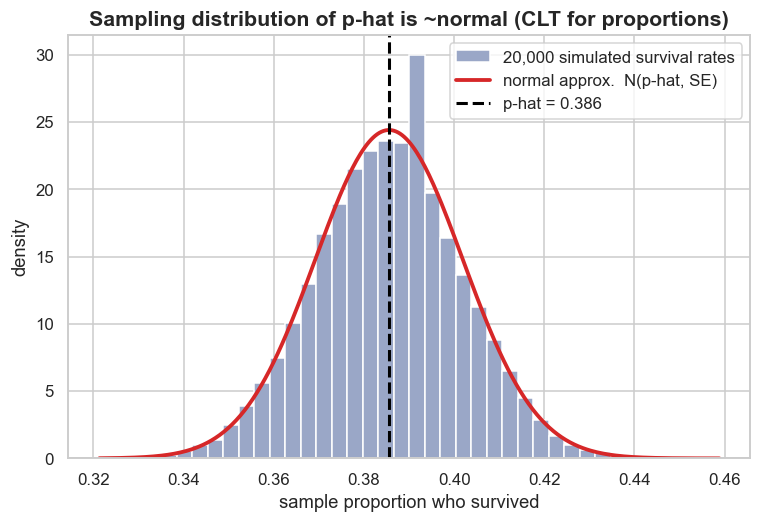

In [5]:
fig, ax = plt.subplots()
ax.hist(sim_phats, bins=40, density=True, color='#9aa7c7', edgecolor='white',
        label='20,000 simulated survival rates')
# Overlay the normal-approximation curve the formula predicts:
xs = np.linspace(sim_phats.min(), sim_phats.max(), 300)
ax.plot(xs, stats.norm.pdf(xs, phat, se_formula), color='#d62728', lw=2.5,
        label='normal approx.  N(p-hat, SE)')
ax.axvline(phat, color='black', ls='--', lw=2, label=f'p-hat = {phat:.3f}')
ax.set_xlabel('sample proportion who survived')
ax.set_ylabel('density')
ax.set_title('Sampling distribution of p-hat is ~normal (CLT for proportions)')
ax.legend(); plt.show()

The simulated histogram is a tidy **bell curve** centered on $\hat{p}$, and the red normal curve built
from the *formula* lands right on top of it. That's the **Central Limit Theorem** working for counts:
even though each passenger is a yes/no outcome, the **proportion** of yeses across many people is
approximately **normal**. This is exactly why the z-based recipes below work.

### When is the normal approximation safe? The success/failure conditions

The bell-curve shortcut needs **enough of both** categories. The standard rule of thumb is

$$n\hat{p} \ge 10 \quad\text{and}\quad n(1-\hat{p}) \ge 10$$

— at least about 10 expected "successes" *and* 10 "failures." With very few of either, the sampling
distribution gets lopsided (it can't go below 0 or above 1), and the normal recipe misbehaves. With 342
survivors and 545 non-survivors, we are nowhere near that danger zone.

In [6]:
print(f'n * p-hat       = {n * phat:.0f}   (survivors)       need >= 10? {n*phat >= 10}')
print(f'n * (1 - p-hat) = {n * (1 - phat):.0f}   (non-survivors)   need >= 10? {n*(1-phat) >= 10}')
print('\nBoth clear 10 by a mile, so the normal-based CI and z-test below are trustworthy.')

n * p-hat       = 342   (survivors)       need >= 10? True
n * (1 - p-hat) = 545   (non-survivors)   need >= 10? True

Both clear 10 by a mile, so the normal-based CI and z-test below are trustworthy.


## 2) A 95% confidence interval for one proportion

Because $\hat{p}$ is approximately normal, a confidence interval is the familiar **estimate ± margin**:

$$\hat{p} \;\pm\; z^{*}\,\sqrt{\dfrac{\hat{p}(1-\hat{p})}{n}}$$

where $z^{*}$ is the normal multiplier — about **1.96** for 95% (compare the *t*-based intervals for
means; for proportions we use the normal $z$ because there's no separate spread to estimate). Read it as
a **range of plausible values** for the true survival rate $p$.

In [7]:
zstar = stats.norm.ppf(0.975)        # 1.96 for 95%
margin = zstar * se_formula
lo, hi = phat - margin, phat + margin
print(f'z* for 95%        = {zstar:.4f}')
print(f'margin of error   = {margin:.4f}  (about +/- {margin*100:.1f} percentage points)')
print(f'95% CI for p      = ({lo:.4f}, {hi:.4f})   ->  ({lo*100:.1f}%, {hi*100:.1f}%)')

# Confirm with statsmodels (it computes the exact same normal interval):
lo_sm, hi_sm = proportion_confint(count=x, nobs=n, alpha=0.05, method='normal')
print(f'\nstatsmodels normal CI = ({lo_sm:.4f}, {hi_sm:.4f})   <- matches our hand calculation')

z* for 95%        = 1.9600
margin of error   = 0.0320  (about +/- 3.2 percentage points)
95% CI for p      = (0.3535, 0.4176)   ->  (35.4%, 41.8%)

statsmodels normal CI = (0.3535, 0.4176)   <- matches our hand calculation


**Interpretation (carefully!):** we're 95% confident the true survival rate lies roughly between
**35.4% and 41.7%**. As in the **confidence-interval flagship**, the "95%" is a property of the *method*
— about 95% of intervals built this way capture the truth — **not** a probability that *this* interval
does. Notice how *narrow* the interval is (only about 3 percentage points either side): with nearly 900
passengers we have pinned the rate down tightly.

## 3) A one-proportion z-test: was survival a coin flip?

Here is a benchmark with real meaning. If being aboard were like a fair coin toss — survive or perish,
50/50 — the true survival rate would be exactly **0.5**. Our $\hat{p}$ came in at 0.386, well under half.
Could that shortfall be chance? This is a **hypothesis test**:

- **Null hypothesis** $H_0:\; p = p_0$ — "survival really was a coin flip, $p_0 = 0.5$."
- **Alternative** $H_A:\; p \neq p_0$ — "the rate was different" (a two-sided test).

The key twist: we **assume $H_0$ is true** while testing it, so we build the SE from $p_0$, **not** from
$\hat{p}$:

$$z = \dfrac{\hat{p} - p_0}{\sqrt{p_0(1-p_0)/n}}.$$

The **p-value** is the chance of seeing a $\hat{p}$ at least this far from $p_0$ *if the null were true*.

### First, see the p-value as an area — by simulating the null world

Let's build the **null distribution** directly: simulate thousands of voyages in a world where survival
really is a fair coin ($p_0 = 0.5$), and see how often a sample lands as far from 0.5 as ours did. The
p-value is just the **share of that null world** at least as extreme as what we observed.

In [8]:
p0 = 0.5                                   # the "coin flip" benchmark we're testing against
obs_dist = abs(phat - p0)                  # how far OUR sample sat from the benchmark

# Simulate the null world: true rate = p0, load n passengers, many times.
null_phats = rng.binomial(n=n, p=p0, size=n_sims) / n
p_value_sim = np.mean(np.abs(null_phats - p0) >= obs_dist)   # two-sided: "at least this far, either way"

print(f'Observed p-hat = {phat:.4f}, which is {obs_dist:.4f} away from p0 = {p0}')
print(f'Biggest gap from 0.5 in {n_sims:,} coin-flip voyages = {np.abs(null_phats - p0).max():.4f}')
print(f'Simulated two-sided p-value = {p_value_sim:.5f}   (= 0; it never happened in these {n_sims:,} sims)')

Observed p-hat = 0.3856, which is 0.1144 away from p0 = 0.5
Biggest gap from 0.5 in 20,000 coin-flip voyages = 0.0772
Simulated two-sided p-value = 0.00000   (= 0; it never happened in these 20,000 sims)


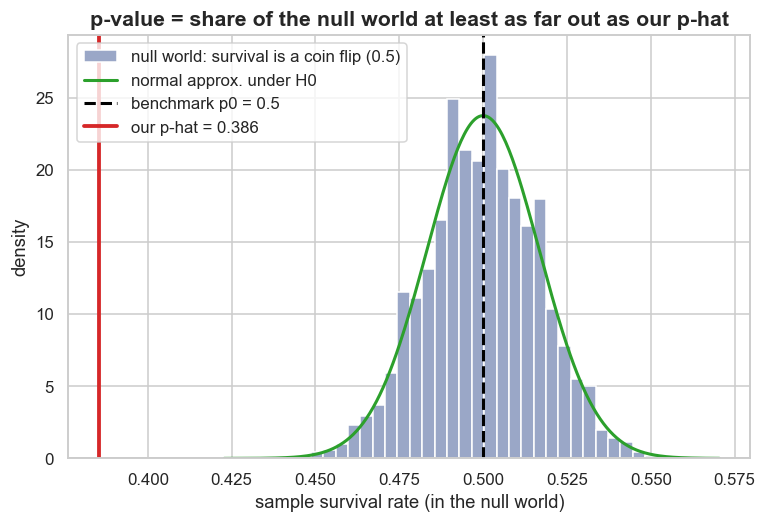

In [9]:
se0 = np.sqrt(p0 * (1 - p0) / n)           # standard error UNDER the null (uses p0, not p-hat)
fig, ax = plt.subplots()
ax.hist(null_phats, bins=40, density=True, color='#9aa7c7', edgecolor='white',
        label=f'null world: survival is a coin flip ({p0})')
xs = np.linspace(null_phats.min(), null_phats.max(), 300)
ax.plot(xs, stats.norm.pdf(xs, p0, se0), color='#2ca02c', lw=2, label='normal approx. under H0')
ax.axvline(p0, color='black', ls='--', lw=2, label=f'benchmark p0 = {p0}')
ax.axvline(phat, color='#d62728', lw=2.5, label=f'our p-hat = {phat:.3f}')
ax.set_xlabel('sample survival rate (in the null world)'); ax.set_ylabel('density')
ax.set_title('p-value = share of the null world at least as far out as our p-hat')
ax.legend(); plt.show()

Our $\hat{p}$ (red) sits **far to the left of everything** the coin-flip world produces — the null
histogram doesn't even reach out to it. A sample like ours is essentially impossible if survival were
50/50, so the p-value is essentially **zero**. Now confirm with the textbook z-formula and statsmodels.

In [10]:
z_stat = (phat - p0) / se0
p_value_formula = 2 * stats.norm.sf(abs(z_stat))     # sf = 1 - CDF; doubled for two-sided
print(f'z-statistic            = {z_stat:.2f}')
print(f'p-value (z-formula)    = {p_value_formula:.2e}')
print(f'p-value (simulation)   = {p_value_sim:.5f}   <- both say: vanishingly small')

# statsmodels: prop_var=p0 tells it to use the NULL value in the SE (the correct test SE).
z_sm, p_sm = proportions_ztest(count=x, nobs=n, value=p0, prop_var=p0)
print(f'\nstatsmodels: z = {z_sm:.2f}, p = {p_sm:.2e}   <- agrees with the formula')

print(f'\nConclusion: p-value is far below 0.05, so we DECISIVELY reject H0.')
print('Survival was not a coin flip -- the true rate was well under half.')

z-statistic            = -6.82
p-value (z-formula)    = 9.36e-12
p-value (simulation)   = 0.00000   <- both say: vanishingly small

statsmodels: z = -6.82, p = 9.36e-12   <- agrees with the formula

Conclusion: p-value is far below 0.05, so we DECISIVELY reject H0.
Survival was not a coin flip -- the true rate was well under half.


Notice the symmetry with the births lesson. There, a benchmark of 8% sat comfortably *inside* the CI, so
the test **did not reject** — the data were consistent with the benchmark. Here, 0.5 sits a country mile
*outside* our CI of (35.4%, 41.7%), so the test rejects hard. As always, **the CI and the test tell the
same story:** values inside the interval survive the test; values far outside it do not.

## 4) Two proportions: did women and men survive at different rates?

Now the question this disaster is remembered for: was a woman's chance of survival different from a
man's? This compares **two** proportions. Start, as always, by *counting* — build the 2×2 table.

In [11]:
table = pd.crosstab(tit['Sex'], tit['Survived'])
table.columns = ['did not survive', 'survived']   # label the 0/1 columns
print(table)

        did not survive  survived
Sex                              
female               81       233
male                464       109


In [12]:
# Group 1 = female, group 2 = male.
x1 = int(table.loc['female', 'survived']);  n1 = int(table.loc['female'].sum())
x2 = int(table.loc['male',   'survived']);  n2 = int(table.loc['male'].sum())
p1, p2 = x1 / n1, x2 / n2
diff = p1 - p2

print(f'female : {x1:>3} survived of {n1:>3}   ->  p1-hat = {p1:.4f}  ({p1*100:.1f}%)')
print(f'male   : {x2:>3} survived of {n2:>3}   ->  p2-hat = {p2:.4f}  ({p2*100:.1f}%)')
print(f'\nobserved difference  p1 - p2 = {diff:.4f}   ({diff*100:.1f} percentage points)')

female : 233 survived of 314   ->  p1-hat = 0.7420  (74.2%)
male   : 109 survived of 573   ->  p2-hat = 0.1902  (19.0%)

observed difference  p1 - p2 = 0.5518   (55.2 percentage points)


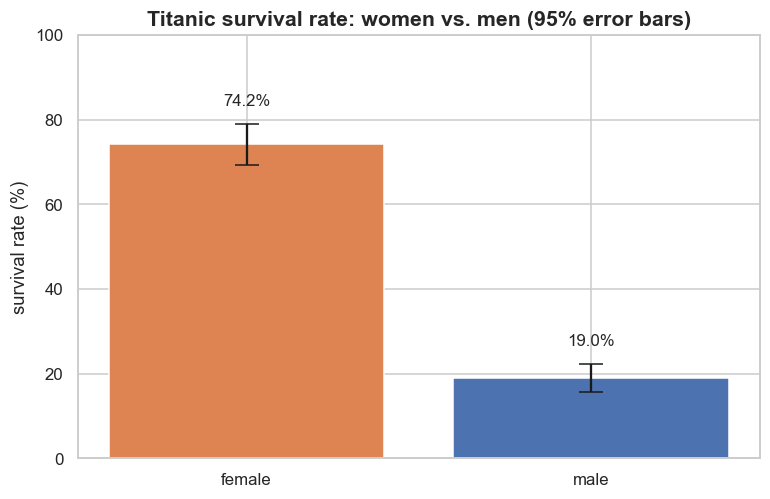

In [13]:
fig, ax = plt.subplots()
groups = ['female', 'male']
rates = [p1 * 100, p2 * 100]
# error bars = +/- 1.96 * each group's own SE (a 95% margin)
errs = [100 * zstar * np.sqrt(pp * (1 - pp) / nn) for pp, nn in [(p1, n1), (p2, n2)]]
bars = ax.bar(groups, rates, yerr=errs, capsize=8,
              color=['#dd8452', '#4c72b0'], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=10)
ax.set_ylabel('survival rate (%)')
ax.set_title('Titanic survival rate: women vs. men (95% error bars)')
ax.set_ylim(0, 100)
plt.show()

The picture is not subtle. About **74%** of the women survived versus about **19%** of the men — a gap of
roughly **55 percentage points**. The error bars (each group's own 95% margin) are tiny next to the gap
and come nowhere close to overlapping. Compare the births lesson, where the two bars were close enough
that you genuinely needed a test to be sure. **Here, the eyes have already decided** — but let's quantify
the gap properly anyway, because the *size* of it is now the interesting quantity.

### A confidence interval for the difference $p_1 - p_2$

For a CI we estimate each group's wobble from its **own** $\hat{p}$ and add the variances (independent
groups):

$$(\hat{p}_1 - \hat{p}_2) \;\pm\; z^{*}\sqrt{\dfrac{\hat{p}_1(1-\hat{p}_1)}{n_1} + \dfrac{\hat{p}_2(1-\hat{p}_2)}{n_2}}.$$

In [14]:
se_diff = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
margin_d = zstar * se_diff
lo_d, hi_d = diff - margin_d, diff + margin_d
print(f'SE of the difference = {se_diff:.4f}')
print(f'95% CI for p1 - p2   = ({lo_d:.4f}, {hi_d:.4f})')
print(f'                     = ({lo_d*100:.1f}, {hi_d*100:.1f}) percentage points')
print('\nThe entire interval sits far ABOVE 0 -- a no-difference of 0 is not remotely plausible.')
print('Even the LOW end of the interval is a ~49-point advantage for women.')

SE of the difference = 0.0296
95% CI for p1 - p2   = (0.4937, 0.6099)
                     = (49.4, 61.0) percentage points

The entire interval sits far ABOVE 0 -- a no-difference of 0 is not remotely plausible.
Even the LOW end of the interval is a ~49-point advantage for women.


This is the teaching point of the whole lesson. In the births data the difference CI was something like
"7 to 22 points" — clearly above 0, but you had to look. Here it is roughly **49 to 61 percentage
points**. The interval isn't doing the job of "is there an effect?" (obviously yes); it's answering
**"how big, and how precisely do we know it?"** Answer: a huge gap, pinned to within about ±6 points.

### A two-proportion z-test

For the **test**, $H_0$ says the two rates are **equal** ($p_1 = p_2$, i.e. their difference is 0). If
they're truly equal, the best estimate of that common rate **pools** both groups together:

$$\hat{p}_{\text{pool}} = \dfrac{x_1 + x_2}{n_1 + n_2}, \qquad
z = \dfrac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}_{\text{pool}}(1-\hat{p}_{\text{pool}})\left(\frac{1}{n_1}+\frac{1}{n_2}\right)}}.$$

We *pool* here (but not for the CI) because the **null assumes one shared rate** — so we use all the data
to estimate it. Let's first **simulate** the null world: shuffle the female/male labels at random so sex
is unrelated to survival, and see how often chance alone produces a gap as big as ours.

In [15]:
# PERMUTATION TEST: under H0 the "sex" label is irrelevant, so reshuffling it
# should give the same survival pattern. Build the null distribution of the gap.
labels = tit['Sex'].to_numpy()
survived = (tit['Survived'] == 1).to_numpy()
n_perm = 20000
null_diffs = np.empty(n_perm)
for i in range(n_perm):
    shuffled = rng.permutation(labels)                      # break any sex<->survival link
    r_female = survived[shuffled == 'female'].mean()
    r_male   = survived[shuffled == 'male'].mean()
    null_diffs[i] = r_female - r_male

p_perm = np.mean(np.abs(null_diffs) >= abs(diff))           # two-sided
print(f'observed gap = {diff:.4f}')
print(f'biggest gap chance produced in {n_perm:,} shuffles = {np.abs(null_diffs).max():.4f}')
print(f'permutation p-value = {p_perm:.5f}   (= 0; the real gap is not even in the same neighborhood)')

observed gap = 0.5518
biggest gap chance produced in 20,000 shuffles = 0.1384
permutation p-value = 0.00000   (= 0; the real gap is not even in the same neighborhood)


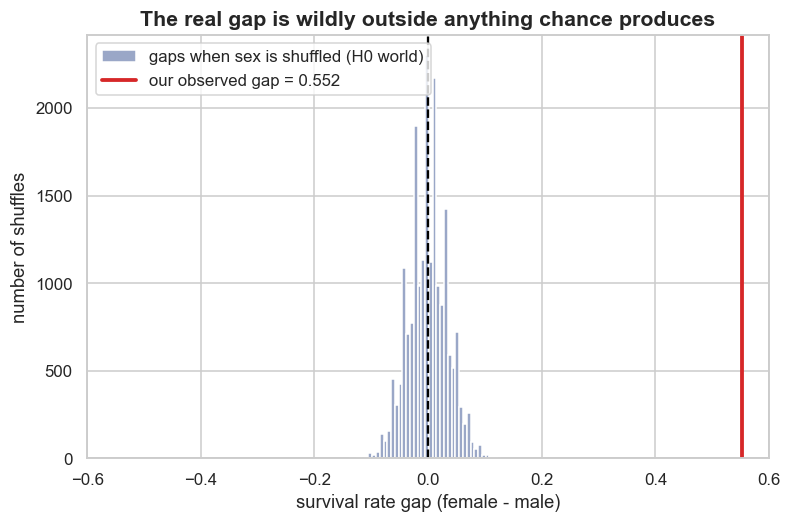

In [16]:
fig, ax = plt.subplots()
ax.hist(null_diffs, bins=40, color='#9aa7c7', edgecolor='white',
        label='gaps when sex is shuffled (H0 world)')
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(diff, color='#d62728', lw=2.5, label=f'our observed gap = {diff:.3f}')
ax.set_xlabel('survival rate gap (female - male)')
ax.set_ylabel('number of shuffles')
ax.set_title('The real gap is wildly outside anything chance produces')
ax.set_xlim(-0.6, 0.6)
ax.legend(); plt.show()

The chance gaps huddle near 0 (a few points either way), while our real gap (red) is parked far out at
**+0.55**, off in empty space. So the p-value is essentially **zero**. Now confirm with the z-formula and
statsmodels.

In [17]:
p_pool = (x1 + x2) / (n1 + n2)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
z_two = diff / se_pool
p_two = 2 * stats.norm.sf(abs(z_two))
print(f'pooled p-hat = {p_pool:.4f}')
print(f'z-statistic  = {z_two:.2f}')
print(f'p-value (z-formula)     = {p_two:.2e}')
print(f'p-value (permutation)   = {p_perm:.5f}   <- both say: astronomically small')

# statsmodels does the pooled two-proportion z-test directly:
z_sm2, p_sm2 = proportions_ztest(count=[x1, x2], nobs=[n1, n2])
print(f'\nstatsmodels: z = {z_sm2:.2f}, p = {p_sm2:.2e}   <- agrees')

pooled p-hat = 0.3856
z-statistic  = 16.15
p-value (z-formula)     = 1.20e-58
p-value (permutation)   = 0.00000   <- both say: astronomically small

statsmodels: z = 16.15, p = 1.20e-58   <- agrees


### Statistical vs. practical significance — the mirror image of a borderline case

A $z$ around **16** is gigantic (recall that $z$ past about 2 already clears the usual 5% bar), and the
p-value is something like $10^{-58}$ — a 1 followed by 58 zeros in the denominator. But fixating on that
p-value here would miss the point. Two ideas often get tangled together:

- **Statistical significance** asks: *could this be chance?* (Here: emphatically no.)
- **Practical significance** asks: *is the effect big enough to matter?* (Here: a 55-point gap — enormous.)

In the births lesson these came apart a little — the effect was real but modest, so the *p-value* carried
the news. **Titanic is the mirror image:** both kinds of significance are overwhelming, so the p-value is
a foregone conclusion and the **informative** number is the **size of the gap and its CI**. The lesson:
when an effect is this large, don't report "p < 0.001" as if it were the discovery — report *"women
survived at roughly 74% versus 19% for men, a gap of about 55 percentage points (95% CI: 49 to 61)."*

### What this does and does **not** prove

- ✅ The female–male survival difference is **statistically significant** and **practically enormous** —
  not a fluke of who happened to be aboard.
- ❌ It does **not** prove that being female *by itself* caused survival. The Titanic was not a randomized
  experiment. The real mechanism was a **"women and children first"** evacuation policy plus where people
  were berthed — sex is bound up with the **actual cause** (priority for the lifeboats). As the
  **relationships** lesson warned: *association is not causation.* The honest sentence is *"in these data,
  sex is strongly associated with survival,"* and the historical reason is the boarding rule, not biology.

## Now you try

Predict first, then change a number and re-run:

1. **Test a different benchmark.** In section 3, change `p0 = 0.5` to `p0 = 0.40`. Now the benchmark is
   close to our $\hat{p}$ of 0.386 — does the test still reject? Is 0.40 inside or outside the 95% CI from
   section 2? (You should find the CI and the test agree.)

2. **A different two-group split.** Swap `Sex` for first-class vs. not. Make a column
   `tit['first'] = np.where(tit['Pclass'] == 1, 'first class', 'lower class')`, then redo the 2×2 table
   and recompute `x1, n1, x2, n2`. Is the survival gap by *class* as huge as the gap by sex, or more
   like the subtle births case?

3. **Re-roll the simulations.** Change `np.random.default_rng(16)` to any other number and re-run the
   one-proportion simulation and the permutation test. Do the simulated SE and the (essentially zero)
   p-values barely move? (They should — that's the point of 20,000 repeats.)

4. **Shrink the data and watch precision drop.** Take a random 100-passenger subset
   (`tit.sample(100, random_state=0)`) and rebuild the one-proportion CI. Does the interval get **wider**?
   Does the conclusion (survival was not a coin flip) still hold with so few people?

## What you learned

- A **proportion** $\hat{p} = x/n$ estimates the unknown true rate $p$; its wobble is the **standard
  error** $\sqrt{\hat{p}(1-\hat{p})/n}$, which you *saw* by simulating the sampling distribution.
- Because $\hat{p}$ is approximately **normal** (CLT for counts) when $n\hat{p}\ge 10$ and
  $n(1-\hat{p})\ge 10$ — conditions Titanic clears easily — a 95% CI is $\hat{p} \pm 1.96\,\text{SE}$.
- A **one-proportion z-test** compares $\hat{p}$ to a benchmark $p_0$ (here the coin-flip 0.5), building
  the SE **from $p_0$**; the **p-value** is the share of the null world at least as extreme as the sample.
- For **two** proportions, the **CI** uses each group's own SE, but the **test pools** the groups because
  $H_0$ assumes one shared rate; a **permutation test** reproduces the same verdict with no formula.
- **The contrast with the core lesson:** the smoker gap was subtle, so the *test* carried the news. The
  female–male survival gap is huge, so significance is a foregone conclusion and the **size of the gap**
  (~55 points) and its **CI** (49 to 61) are what matter — **statistical vs. practical significance**,
  both overwhelming here.
- **Significant ≠ causal:** sex is strongly *associated* with Titanic survival, but the cause was the
  "women and children first" boarding rule, not sex itself — association is not causation.

---

**↩ Back to the lesson:** [Lesson 14: Inference for proportions (one & two)](14-inference-proportions.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](14-inference-proportions~the-code.ipynb)